In [8]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# Set the path to the file you'd like to load
file_path = "employee_salary_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prince7489/employee-salary-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-2534759374.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'employee-salary-dataset' dataset.
First 5 records:    EmployeeID        Name  Department  Experience_Years Education_Level  Age  \
0           1  Employee_1   Marketing                15          Master   53   
1           2  Employee_2  Operations                 7        Bachelor   25   
2           3  Employee_3          IT                12     High School   51   
3           4  Employee_4  Operations                 8             PhD   44   
4           5  Employee_5  Operations                15          Master   36   

   Gender       City  Monthly_Salary  
0  Female      Delhi          111416  
1  Female  Bangalore           95271  
2  Female  Hyderabad           69064  
3    Male      Delhi           95091  
4  Female      Delhi          132450  


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
df

,EmployeeID,Name,Department,Experience_Years,Education_Level,Age,Gender,City,Monthly_Salary
0,1,Employee_1,Marketing,15,Master,53,Female,Delhi,111416
1,2,Employee_2,Operations,7,Bachelor,25,Female,Bangalore,95271
2,3,Employee_3,IT,12,High School,51,Female,Hyderabad,69064
3,4,Employee_4,Operations,8,PhD,44,Male,Delhi,95091
4,5,Employee_5,Operations,15,Master,36,Female,Delhi,132450
5,6,Employee_6,Finance,3,High School,50,Male,Mumbai,65818
6,7,Employee_7,IT,14,PhD,57,Male,Mumbai,70525
7,8,Employee_8,IT,17,PhD,34,Female,Bangalore,44830
8,9,Employee_9,IT,4,Bachelor,53,Male,Hyderabad,42429
9,10,Employee_10,Operations,18,High School,28,Male,Mumbai,31893


In [12]:
df.shape

(50, 9)

In [13]:
#Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
#Removing Duplicates
df=df.drop_duplicates()

In [15]:
#Checking for null values
df.isnull().sum()

,0
EmployeeID,0
Name,0
Department,0
Experience_Years,0
Education_Level,0
Age,0
Gender,0
City,0
Monthly_Salary,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   EmployeeID        50 non-null     int64 
 1   Name              50 non-null     object
 2   Department        50 non-null     object
 3   Experience_Years  50 non-null     int64 
 4   Education_Level   50 non-null     object
 5   Age               50 non-null     int64 
 6   Gender            50 non-null     object
 7   City              50 non-null     object
 8   Monthly_Salary    50 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ KB


In [17]:
df.describe()

,EmployeeID,Experience_Years,Age,Monthly_Salary
count,50.00000,50.000000,50.000000,50.0000
mean,25.50000,9.900000,39.760000,82288.8000
std,14.57738,5.349995,11.539745,33521.4379
min,1.00000,1.000000,22.000000,28420.0000
25%,13.25000,5.250000,28.250000,59424.0000
50%,25.50000,10.000000,43.500000,73890.5000
75%,37.75000,14.750000,49.000000,107219.0000
max,50.00000,19.000000,57.000000,149123.0000


In [20]:
#Finding Correlation
# Select only numerical columns for correlation calculation
numerical_df = df[['Experience_Years', 'Age', 'Monthly_Salary']]
cn = numerical_df.corr()
cn

,Experience_Years,Age,Monthly_Salary
Experience_Years,1.000000,0.130837,0.074221
Age,0.130837,1.000000,0.060972
Monthly_Salary,0.074221,0.060972,1.000000


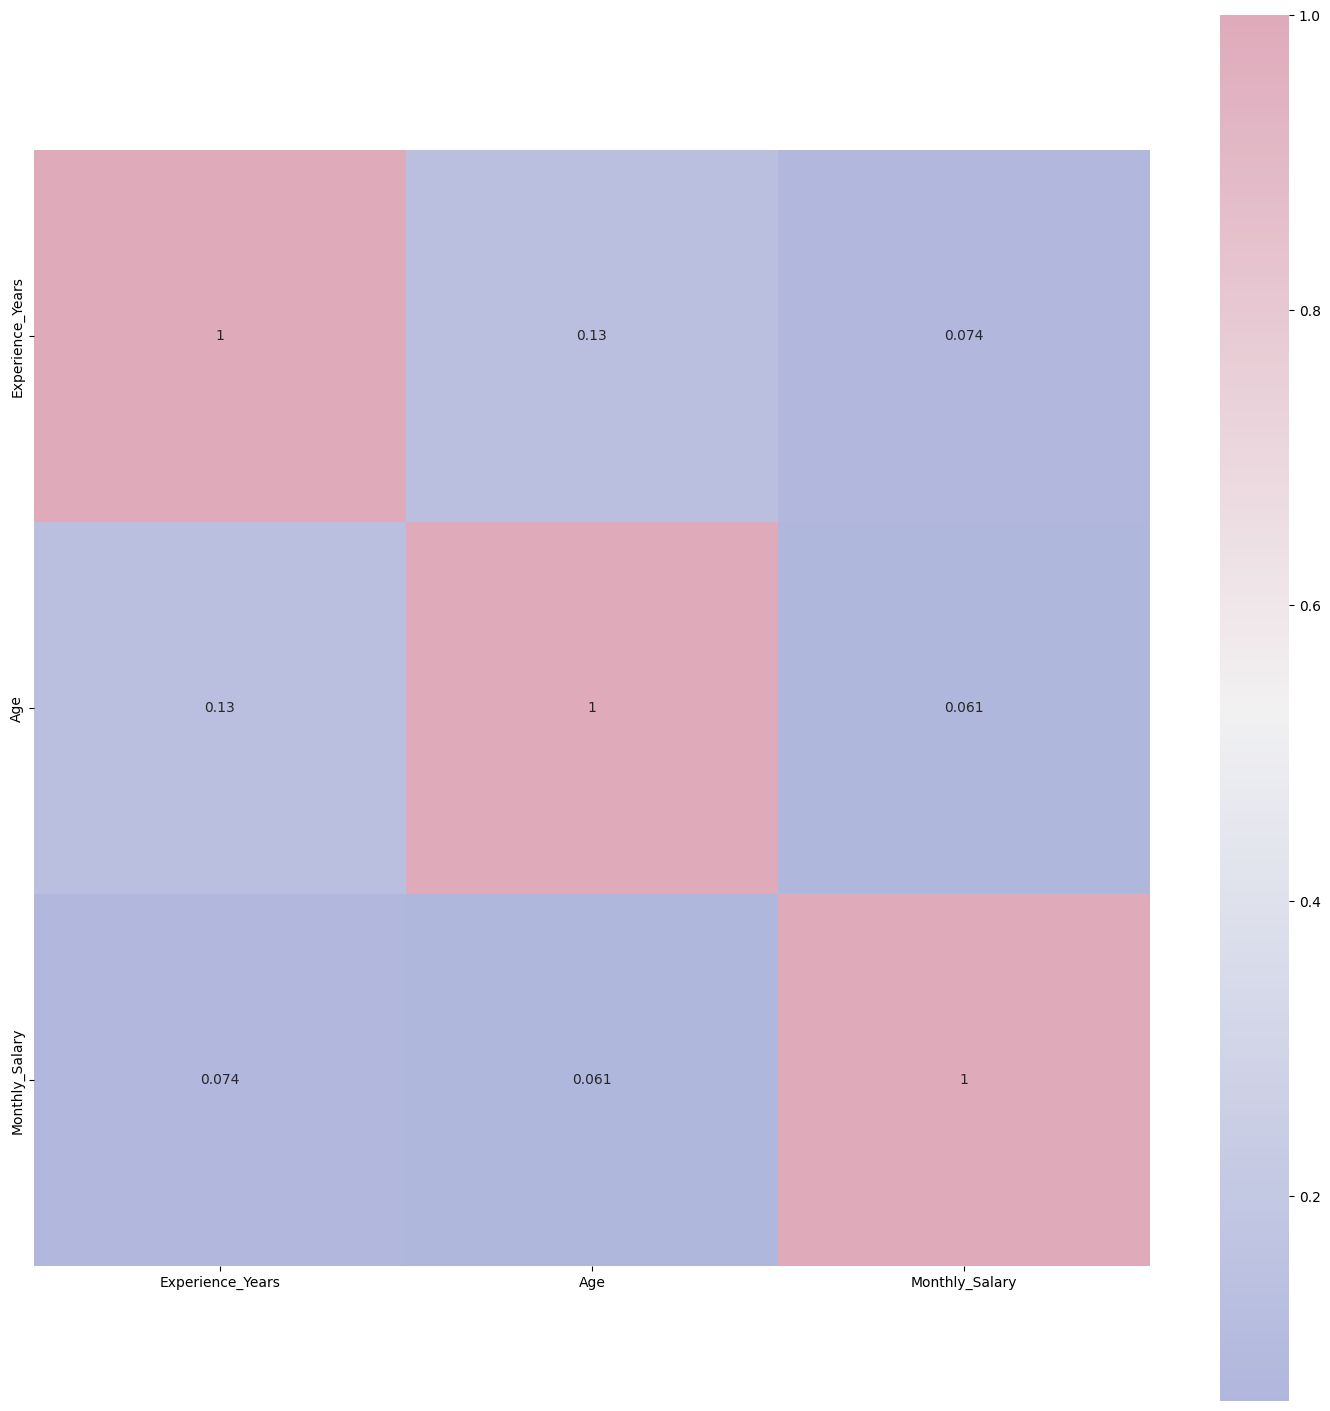

In [21]:
#Correlation
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap=cmap,annot=True, square=True)
plt.show()

<Axes: >

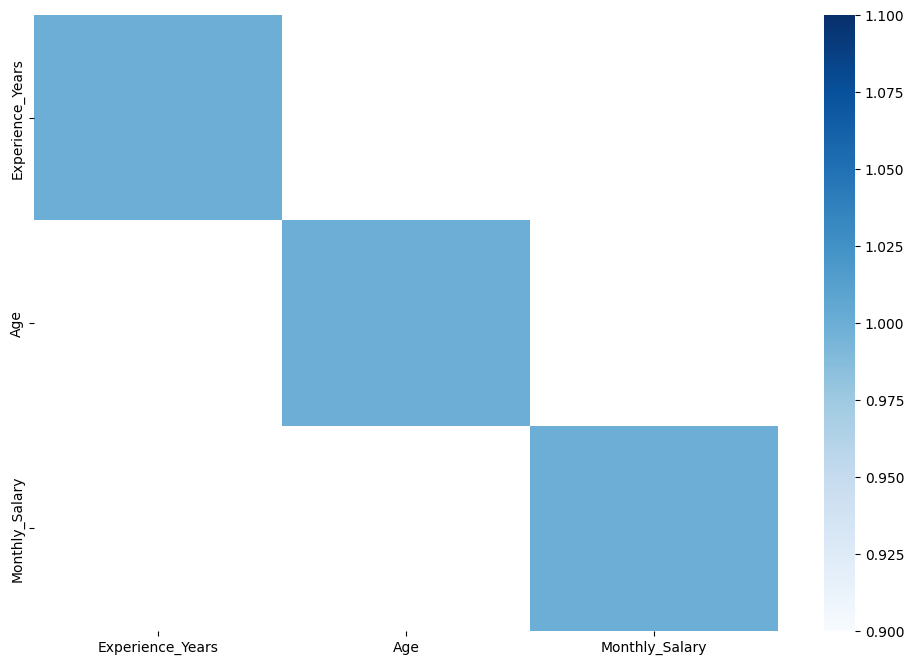

In [22]:
kot = cn[cn>=.40]
plt.figure(figsize=(12,8))
sns.heatmap(kot, cmap="Blues")

In [24]:
#Splitting data for training and testing
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['Experience_Years', 'Age']]
y = df['Monthly_Salary']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.25, random_state=0)